#### Setup y Configuración

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from config import BRONZE_DIR

# Configuración visual profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Ruta del Parquet limpio
PARQUET_PATH = BRONZE_DIR / "rips_limpio.parquet"
print(f"Archivo: {PARQUET_PATH}")
print(f"Tamaño: {PARQUET_PATH.stat().st_size / (1024**3):.2f} GB")

# Conectar a DuckDB
con = duckdb.connect()

Archivo: C:\Users\ASUS I7\Documents\rips-colombia-health-segmentation\notebooks\..\data\bronze\rips_limpio.parquet
Tamaño: 0.09 GB


####  Estadísticas Globales del Dataset

In [2]:
stats = con.execute(f"""
    SELECT 
        COUNT(*) as total_registros,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(DISTINCT cod_departamento) as n_deptos,
        COUNT(DISTINCT cod_municipio) as n_municipios,
        COUNT(DISTINCT Año) as n_anios,
        COUNT(DISTINCT TipoAtencion) as n_tipos_atencion,
        COUNT(DISTINCT Diagnostico) as n_diagnosticos,
        ROUND(AVG(NumeroAtenciones)::FLOAT, 2) as media_atenciones,
        ROUND(MEDIAN(NumeroAtenciones)::FLOAT, 2) as mediana_atenciones,
        ROUND(MIN(NumeroAtenciones)::FLOAT, 2) as min_atenciones,
        ROUND(MAX(NumeroAtenciones)::FLOAT, 2) as max_atenciones
    FROM '{PARQUET_PATH}'
""").fetchdf()

print("=== ESTADÍSTICAS GLOBALES ===")
print(stats.T)  # Transponer para mejor visualización

# Guardar para referencia futura
stats.to_csv('../reports/estadisticas_globales.csv', index=False)

=== ESTADÍSTICAS GLOBALES ===
                               0
total_registros     2.500084e+07
total_atenciones    2.529929e+09
n_deptos            2.600000e+01
n_municipios        1.075000e+03
n_anios             1.300000e+01
n_tipos_atencion    4.000000e+00
n_diagnosticos      1.264200e+04
media_atenciones    1.011900e+02
mediana_atenciones  3.000000e+00
min_atenciones      1.000000e+00
max_atenciones      1.861965e+07


#### Distribución de NumeroAtenciones (Percentiles)

In [3]:
percentiles = con.execute(f"""
    SELECT 
        ROUND(PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p50,
        ROUND(PERCENTILE_DISC(0.75) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p75,
        ROUND(PERCENTILE_DISC(0.9) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p90,
        ROUND(PERCENTILE_DISC(0.95) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p95,
        ROUND(PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p99,
        ROUND(PERCENTILE_DISC(0.999) WITHIN GROUP (ORDER BY NumeroAtenciones)::FLOAT, 2) as p999
    FROM '{PARQUET_PATH}'
""").fetchdf()

print("=== PERCENTILES DE NumeroAtenciones ===")
print(percentiles.T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== PERCENTILES DE NumeroAtenciones ===
            0
p50       3.0
p75      10.0
p90      42.0
p95     111.0
p99     863.0
p999  10347.0


#### Distribución por Tipo de Atención

=== DISTRIBUCIÓN POR TIPO DE ATENCIÓN ===
              TipoAtencion  n_registros  total_atenciones  pct_atenciones
0  PROCEDIMIENTOS DE SALUD      6734009      1.517249e+09           59.97
1                CONSULTAS     13069272      9.512275e+08           37.60
2                URGENCIAS      2870763      4.393782e+07            1.74
3        HOSPITALIZACIONES      2326798      1.751528e+07            0.69


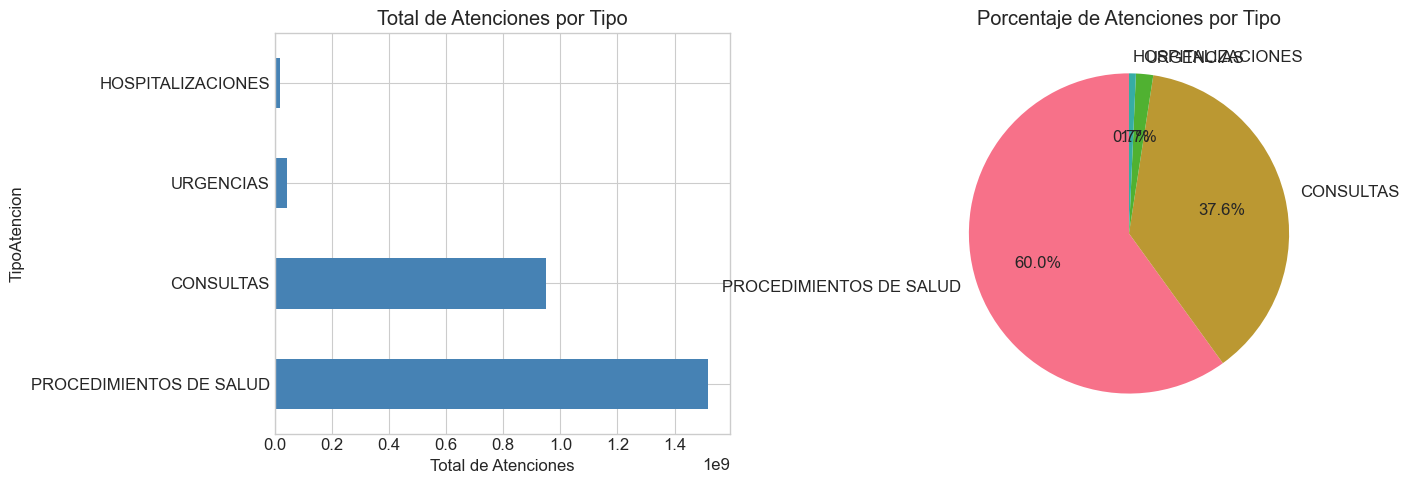

In [4]:
distribucion_tipos = con.execute(f"""
    SELECT 
        TipoAtencion,
        COUNT(*) as n_registros,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND(SUM(NumeroAtenciones) * 100.0 / (SELECT SUM(NumeroAtenciones) FROM '{PARQUET_PATH}'), 2) as pct_atenciones
    FROM '{PARQUET_PATH}'
    GROUP BY TipoAtencion
    ORDER BY total_atenciones DESC
""").fetchdf()

print("=== DISTRIBUCIÓN POR TIPO DE ATENCIÓN ===")
print(distribucion_tipos)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras horizontales
distribucion_tipos.plot(x='TipoAtencion', y='total_atenciones', kind='barh', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Total de Atenciones por Tipo')
axes[0].set_xlabel('Total de Atenciones')

# Torta
axes[1].pie(distribucion_tipos['pct_atenciones'], labels=distribucion_tipos['TipoAtencion'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Porcentaje de Atenciones por Tipo')

plt.tight_layout()
plt.savefig('../reports/figures/03_distribucion_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Top 10 Diagnósticos (por Volumen de Atenciones)

=== TOP 10 DIAGNÓSTICOS POR ATENCIONES ===
                                         Diagnostico  total_atenciones  \
0            I10X - HIPERTENSION ESENCIAL (PRIMARIA)       115859841.0   
1                       Z000 - EXAMEN MEDICO GENERAL        86915743.0   
2  R688 - OTROS SINTOMAS Y SIGNOS GENERALES ESPEC...        85491871.0   
3                        K021 - CARIES DE LA DENTINA        61312190.0   
4                       Z017 - EXAMEN DE LABORATORIO        61010290.0   
5                         Z012 - EXAMEN ODONTOLOGICO        41652938.0   
6         Z001 - CONTROL DE SALUD DE RUTINA DEL NIÑO        29456681.0   
7  R104 - OTROS DOLORES ABDOMINALES Y LOS NO ESPE...        25633927.0   
8  Z768 - PERSONA EN CONTACTO CON LOS SERVICIOS D...        25109049.0   
9  N390 - INFECCION DE VIAS URINARIAS, SITIO NO E...        24052657.0   

   n_registros  pct_atenciones  
0        31363            4.58  
1        23990            3.44  
2        24432            3.38  
3        1

C:\Temp\ipykernel_10548\3470830787.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


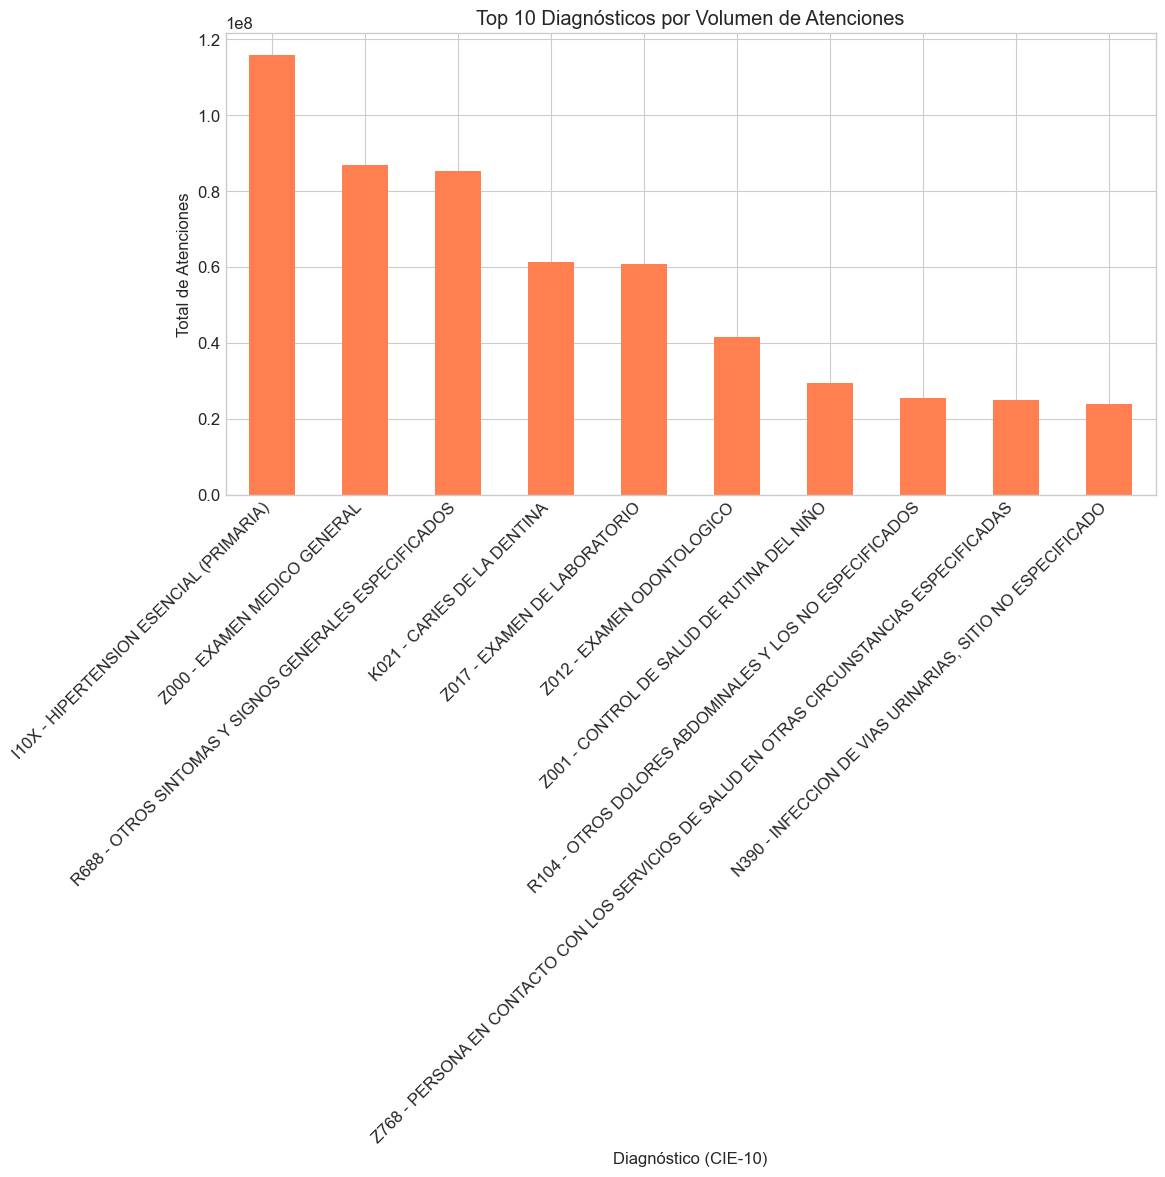

In [5]:
top_diagnosticos = con.execute(f"""
    SELECT 
        Diagnostico,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(*) as n_registros,
        ROUND(SUM(NumeroAtenciones) * 100.0 / (SELECT SUM(NumeroAtenciones) FROM '{PARQUET_PATH}'), 2) as pct_atenciones
    FROM '{PARQUET_PATH}'
    WHERE NOT es_no_definido  -- Excluimos NO DEFINIDO para ver el resto
    GROUP BY Diagnostico
    ORDER BY total_atenciones DESC
    LIMIT 10
""").fetchdf()

print("=== TOP 10 DIAGNÓSTICOS POR ATENCIONES ===")
print(top_diagnosticos)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
top_diagnosticos.plot(x='Diagnostico', y='total_atenciones', kind='bar', ax=ax, color='coral', legend=False)
ax.set_title('Top 10 Diagnósticos por Volumen de Atenciones')
ax.set_xlabel('Diagnóstico (CIE-10)')
ax.set_ylabel('Total de Atenciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_top_diagnosticos.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar resultados
top_diagnosticos.to_csv('../reports/top_diagnosticos.csv', index=False)

#### Análisis de "NO DEFINIDO" por Departamento

=== 'NO DEFINIDO' POR DEPARTAMENTO (TOP 10) ===
  nombre_departamento  n_registros  atenciones_no_def  total_atenciones  \
0            Casanare        13114           746731.0         1303358.0   
1               Cauca       999104         29890558.0        60968665.0   
2              Nariño      1505072         39792900.0       102975068.0   
3     Valle del Cauca      1613478         90821612.0       248697097.0   
4               Cesar       662324         19885414.0        58237713.0   
5             Caquetá       377667          7179009.0        21401863.0   
6             Quindio       402567         10222715.0        31230563.0   
7              Caldas       674686         15069191.0        46076690.0   
8           Santander      1458224         36870214.0       118996565.0   
9          La Guajira       442321         12854603.0        42368340.0   

   pct_no_def  pct_registros_no_def  
0       57.29                  0.03  
1       49.03                  0.03  
2       38.6

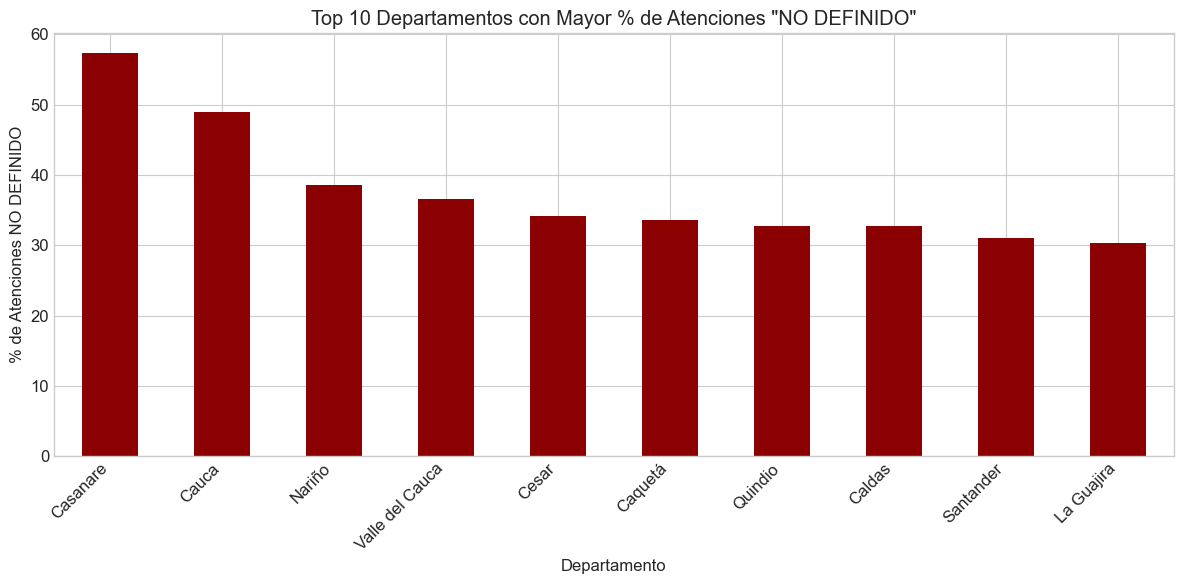

In [6]:
no_definido_depto = con.execute(f"""
    SELECT 
        nombre_departamento,
        COUNT(*) as n_registros,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND((SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 / SUM(NumeroAtenciones)), 2) as pct_no_def,
        ROUND((SUM(CASE WHEN es_no_definido THEN 1 ELSE 0 END) * 100.0 / COUNT(*)), 2) as pct_registros_no_def
    FROM '{PARQUET_PATH}'
    WHERE nombre_departamento IS NOT NULL
    GROUP BY nombre_departamento
    ORDER BY pct_no_def DESC
""").fetchdf()

print("=== 'NO DEFINIDO' POR DEPARTAMENTO (TOP 10) ===")
print(no_definido_depto.head(10))

# Visualización - Top 10 departamentos con mayor % de NO DEFINIDO
fig, ax = plt.subplots(figsize=(12, 6))
no_definido_depto.head(10).plot(x='nombre_departamento', y='pct_no_def', kind='bar', ax=ax, color='darkred', legend=False)
ax.set_title('Top 10 Departamentos con Mayor % de Atenciones "NO DEFINIDO"')
ax.set_xlabel('Departamento')
ax.set_ylabel('% de Atenciones NO DEFINIDO')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_no_definido_deptos.png', dpi=150, bbox_inches='tight')
plt.show()

#### "NO DEFINIDO" por Tipo de Atención

=== 'NO DEFINIDO' POR TIPO DE ATENCIÓN ===
              TipoAtencion  n_registros  atenciones_no_def  total_atenciones  \
0  PROCEDIMIENTOS DE SALUD      6734009        654848278.0      1.517249e+09   
1                CONSULTAS     13069272               35.0      9.512275e+08   
2                URGENCIAS      2870763               74.0      4.393782e+07   
3        HOSPITALIZACIONES      2326798               14.0      1.751528e+07   

   pct_no_def  
0       43.16  
1        0.00  
2        0.00  
3        0.00  


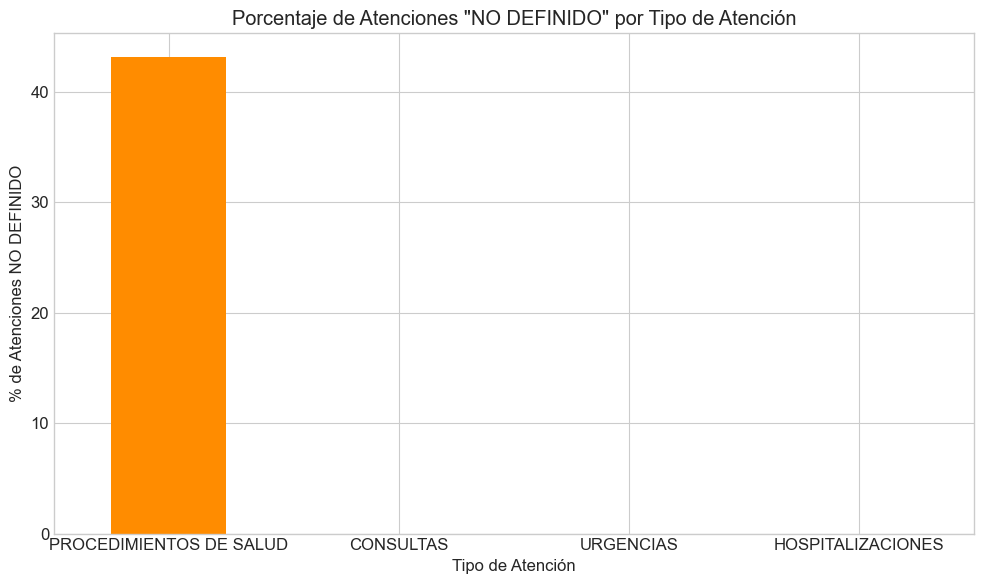

In [7]:
no_definido_tipo = con.execute(f"""
    SELECT 
        TipoAtencion,
        COUNT(*) as n_registros,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND((SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 / SUM(NumeroAtenciones)), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    GROUP BY TipoAtencion
    ORDER BY pct_no_def DESC
""").fetchdf()

print("=== 'NO DEFINIDO' POR TIPO DE ATENCIÓN ===")
print(no_definido_tipo)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
no_definido_tipo.plot(x='TipoAtencion', y='pct_no_def', kind='bar', ax=ax, color='darkorange', legend=False)
ax.set_title('Porcentaje de Atenciones "NO DEFINIDO" por Tipo de Atención')
ax.set_xlabel('Tipo de Atención')
ax.set_ylabel('% de Atenciones NO DEFINIDO')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/03_no_definido_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Departamentos con Mayor Concentración de Atenciones

=== TOP 15 DEPARTAMENTOS POR VOLUMEN DE ATENCIONES ===
   nombre_departamento  total_atenciones  pct_atenciones
0         Bogotá, D.C.       487962479.0           19.29
1            Antioquia       312958878.0           12.37
2      Valle del Cauca       248697097.0            9.83
3            Atlántico       140374896.0            5.55
4         Cundinamarca       119663673.0            4.73
5            Santander       118996565.0            4.70
6               Nariño       102975068.0            4.07
7              Bolívar        96514600.0            3.81
8              Córdoba        75528495.0            2.99
9                Huila        69259547.0            2.74
10              Boyacá        65316701.0            2.58
11               Cauca        60968665.0            2.41
12  Norte de Santander        60402803.0            2.39
13               Cesar        58237713.0            2.30
14           Magdalena        56485806.0            2.23


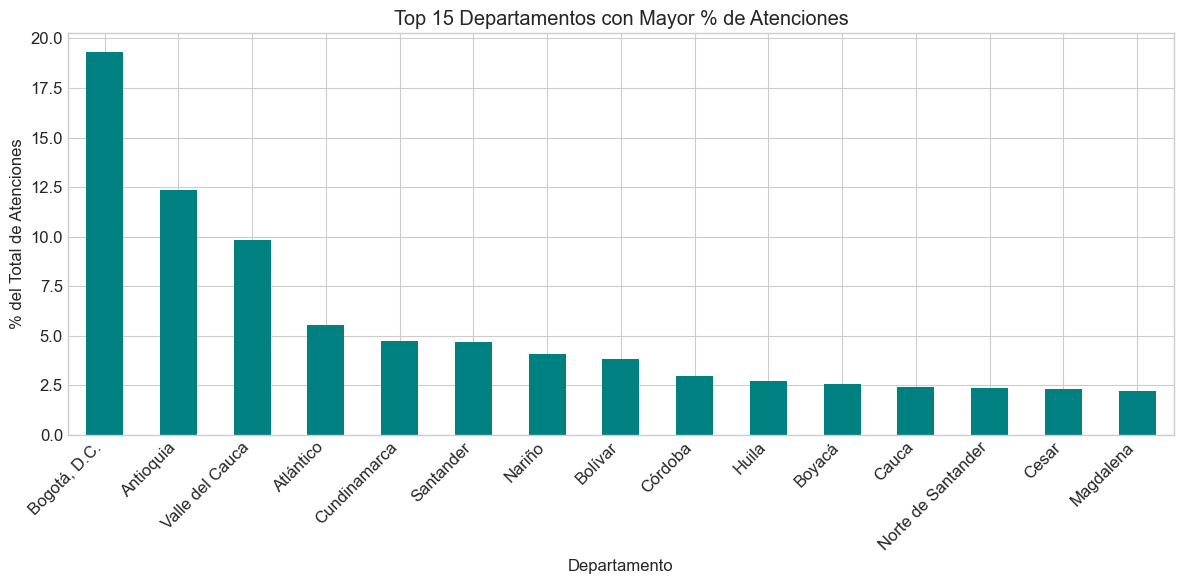

In [8]:
concentracion_deptos = con.execute(f"""
    SELECT 
        nombre_departamento,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND(SUM(NumeroAtenciones) * 100.0 / (SELECT SUM(NumeroAtenciones) FROM '{PARQUET_PATH}'), 2) as pct_atenciones
    FROM '{PARQUET_PATH}'
    WHERE nombre_departamento IS NOT NULL
    GROUP BY nombre_departamento
    ORDER BY total_atenciones DESC
    LIMIT 15
""").fetchdf()

print("=== TOP 15 DEPARTAMENTOS POR VOLUMEN DE ATENCIONES ===")
print(concentracion_deptos)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
concentracion_deptos.plot(x='nombre_departamento', y='pct_atenciones', kind='bar', ax=ax, color='teal', legend=False)
ax.set_title('Top 15 Departamentos con Mayor % de Atenciones')
ax.set_xlabel('Departamento')
ax.set_ylabel('% del Total de Atenciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_concentracion_deptos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Resumen y Guardado de Resultados

In [9]:
# Crear resumen ejecutivo
resumen = {
    'Metrica': ['Total Registros', 'Total Atenciones', 'Departamentos', 'Municipios', 'Años', 'Tipos de Atención', 'Diagnósticos'],
    'Valor': [
        stats['total_registros'].iloc[0],
        stats['total_atenciones'].iloc[0],
        stats['n_deptos'].iloc[0],
        stats['n_municipios'].iloc[0],
        stats['n_anios'].iloc[0],
        stats['n_tipos_atencion'].iloc[0],
        stats['n_diagnosticos'].iloc[0]
    ]
}
resumen_df = pd.DataFrame(resumen)

# Guardar resumen
resumen_df.to_csv('../reports/resumen_datos.csv', index=False)

print("=== RESUMEN DEL DATASET ===")
print(resumen_df)

print("\n✅ Notebook 03 completado. Resultados guardados en reports/")

=== RESUMEN DEL DATASET ===
             Metrica         Valor
0    Total Registros  2.500084e+07
1   Total Atenciones  2.529929e+09
2      Departamentos  2.600000e+01
3         Municipios  1.075000e+03
4               Años  1.300000e+01
5  Tipos de Atención  4.000000e+00
6       Diagnósticos  1.264200e+04

✅ Notebook 03 completado. Resultados guardados en reports/
